<a href="https://colab.research.google.com/github/jnahMoch/revisedBookRecommender/blob/main/Books_categorizing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

booksDF = pd.read_csv('cleaned_books_dataset.csv')
booksDF['cleaned_description'] = booksDF['cleaned_description'].fillna('')

In [ ]:
booksDF.head()

,isbn13,isbn10,title,authors,categories,description,thumbnail,average_rating,num_pages,cleaned_description
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,A NOVEL THAT READERS and critics have been eag...,http://books.google.com/books/content?id=KQZCP...,3.85,247.0,novel reader critic eagerly anticipating decad...
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Fiction,A new 'Christie for Christmas' -- a full-lengt...,http://books.google.com/books/content?id=gA5GP...,3.83,241.0,new christie christmas fulllength novel adapte...
2,9780006163831,0006163831,The One Tree,Stephen R. Donaldson,Fiction,Volume Two of Stephen Donaldson's acclaimed se...,http://books.google.com/books/content?id=OmQaw...,3.97,479.0,volume two stephen donaldsons acclaimed second...
3,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,"A memorable, mesmerizing heroine Jennifer -- b...",http://books.google.com/books/content?id=FKo2T...,3.93,512.0,memorable mesmerizing heroine jennifer brillia...
4,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Religion,Lewis' work on the nature of love divides love...,http://books.google.com/books/content?id=XhQ5X...,4.15,170.0,lewis work nature love divide love four catego...


In [ ]:
category_mapping = {
    'Fiction': 'fiction', 'Juvenile Fiction': "children's fiction",
    'Biography & Autobiography': 'nonfiction', 'History': 'nonfiction',
    'Literary Criticism': 'nonfiction', 'Philosophy': 'nonfiction',
    'Religion': 'nonfiction', 'Comics & Graphic Novels': 'fiction',
    'Drama': 'fiction', 'Juvenile Nonfiction': "children's non-fiction",
    'Poetry': 'fiction'
}
booksDF['target_category'] = booksDF['categories'].map(category_mapping)

In [ ]:
train_df = booksDF.dropna(subset=['target_category']).copy()
X = train_df['cleaned_description']
y = train_df['target_category']

# Stratified Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
vectorizer = TfidfVectorizer(max_features=12000, ngram_range=(1, 2), sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LinearSVC(class_weight='balanced', C=0.5, random_state=42, max_iter=2000)
model.fit(X_train_vec, y_train)

LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)

--- MODEL EVALUATION REPORT ---
Overall Accuracy: 0.8110

                        precision    recall  f1-score   support

    children's fiction       0.71      0.48      0.57       105
children's non-fiction       0.33      0.05      0.08        22
               fiction       0.83      0.91      0.87       619
            nonfiction       0.78      0.77      0.77       233

              accuracy                           0.81       979
             macro avg       0.67      0.55      0.57       979
          weighted avg       0.80      0.81      0.80       979



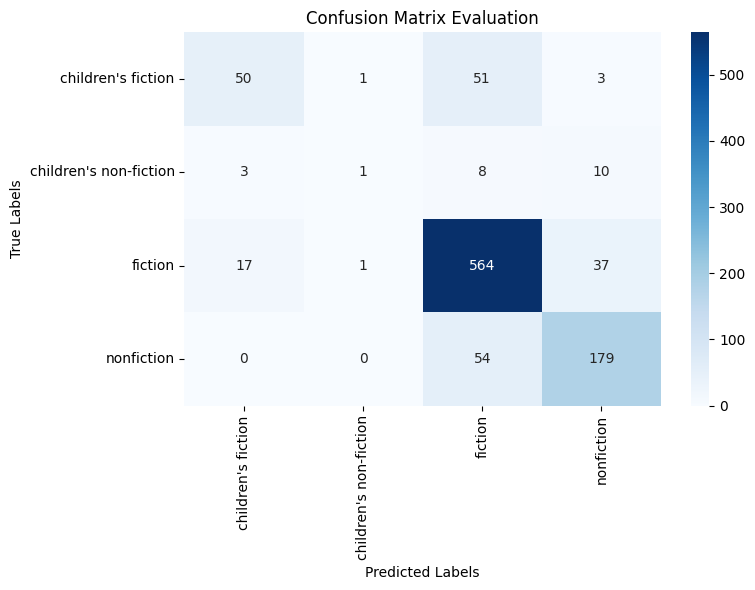

In [ ]:
y_pred = model.predict(X_test_vec)

print("--- MODEL EVALUATION REPORT ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_, ax=ax)
ax.set_title('Confusion Matrix Evaluation')
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
plt.tight_layout()
plt.show()

In [ ]:
X_full_vec = vectorizer.transform(booksDF['cleaned_description'])
booksDF['simple_categories'] = model.predict(X_full_vec)

booksDF.drop(columns=['target_category'], errors='ignore', inplace=True)
booksDF.to_csv('cleaned_books_dataset_with_simple_categories2.csv', index=False)

In [ ]:
BooksCatDF =pd.read_csv("cleaned_books_dataset_with_simple_categories2.csv")
BooksCatDF.head(5)

,isbn13,isbn10,title,authors,categories,description,thumbnail,average_rating,num_pages,cleaned_description,simple_categories
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,A NOVEL THAT READERS and critics have been eag...,http://books.google.com/books/content?id=KQZCP...,3.85,247.0,novel reader critic eagerly anticipating decad...,fiction
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Fiction,A new 'Christie for Christmas' -- a full-lengt...,http://books.google.com/books/content?id=gA5GP...,3.83,241.0,new christie christmas fulllength novel adapte...,fiction
2,9780006163831,0006163831,The One Tree,Stephen R. Donaldson,Fiction,Volume Two of Stephen Donaldson's acclaimed se...,http://books.google.com/books/content?id=OmQaw...,3.97,479.0,volume two stephen donaldsons acclaimed second...,fiction
3,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,"A memorable, mesmerizing heroine Jennifer -- b...",http://books.google.com/books/content?id=FKo2T...,3.93,512.0,memorable mesmerizing heroine jennifer brillia...,fiction
4,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Religion,Lewis' work on the nature of love divides love...,http://books.google.com/books/content?id=XhQ5X...,4.15,170.0,lewis work nature love divide love four catego...,nonfiction
